Link the schema here for reference

Begin

In [260]:

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import astropy.units as u

from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.nddata import Cutout2D
from astropy.table import QTable
from astropy.stats import SigmaClip

from astroquery.gaia import Gaia

from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
from photutils.centroids import centroid_quadratic

from synphot import Observation, SpectralElement, SourceSpectrum, BlackBodyNorm1D
from synphot import units as su

from spextra import Spextrum


In [209]:
# create the master calibration table

cal_table = QTable()

# # dao params
# cal_table["x_centroid"] = [] * u.pix
# cal_table["y_centroid"] = [] * u.pix
# cal_table["oiii_raw_sum"] = [] * u.electron / u.s
# cal_table["oiiic_raw_sum"] = [] * u.electron / u.s
# cal_table["oiii_rate"] = [] * u.electron / u.s
# cal_table["oiiic_rate"] = [] * u.electron / u.s
# cal_table["flux_ratio"] = []

# # cal_table["simulated_flux"] = [] * u.photon / u.s

# # gaia params
# cal_table["ra"] = [] * u.deg
# cal_table["dec"] = [] * u.deg
# cal_table["source_id"] = []
# cal_table["phot_bp_mean_mag"] = []
# cal_table["teff_gspphot"] = [] * u.K
# cal_table["spectraltype_esphs"] = []

# final scale factor for both oiii and oiiic from the measured and simulated fluxes
		
  
cal_table = QTable(
    names=[
        "x_centroid",
        "y_centroid",
        "oiii_raw_sum",
        "oiiic_raw_sum",
        "oiii_rate",
        "oiiic_rate",
        "ra",
        "dec",
        "source_id",
        "phot_bp_mean_mag",
        "teff_gspphot",
        "spectraltype_esphs",
        "flux_ratio",
    ],
    dtype=[
        float,
        float,
        float,
        float,
        float,
        float,
        float,
        float,
        "i8",       # 64-bit Gaia source ID
        float,
        float,
        "U20",      # spectral-type text
        float,
    ],
    units=[
        u.pix,
        u.pix,
        u.electron / u.s,
        u.electron / u.s,
        u.electron / u.s,
        u.electron / u.s,
        u.deg,
        u.deg,
        None,
        u.mag,
        u.K,
        None,
        None,
    ]
)
  
print(cal_table)

x_centroid y_centroid oiii_raw_sum ... spectraltype_esphs flux_ratio
   pix        pix     electron / s ...                              
---------- ---------- ------------ ... ------------------ ----------


In [210]:
# open the images
oiii_hdu = fits.open("images/normalized_OIII.fits")
oiiic_hdu = fits.open("images/normalized_OIIIC.fits")
wcs_hdul = fits.open("images/SNR_OIII.fits")

# images
oiii_image = oiii_hdu[0].data
oiiic_image = oiiic_hdu[0].data

# image headers
oiii_header = oiii_hdu[0].header
oiiic_header = oiiic_hdu[0].header

# create WCS
wcs = WCS(wcs_hdul["SCI"].header)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 86.9519162984652 -70.4145638364921 
CRPIX : 1567.851522483014 1069.07832988416 
CD1_1 CD1_2  : -1.1558431745326e-05 4.30113955981334e-05 
CD2_1 CD2_2  : -4.291815952434e-05 -1.1548898773803e-05 
NAXIS : 3164  2175

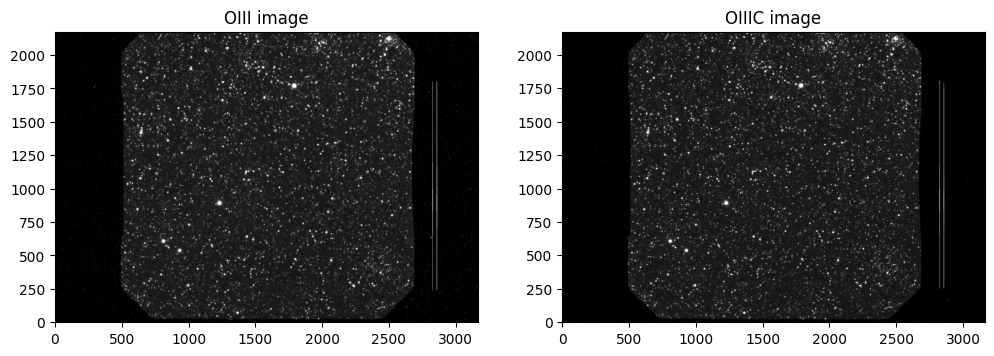

In [211]:
# plot image previews
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(oiii_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiii_image, 5), vmax=np.nanpercentile(oiii_image, 99.5))
ax1.set_title("OIII image")

ax2.imshow(oiiic_image, origin="lower", cmap="gray", vmin=np.nanpercentile(oiiic_image, 5), vmax=np.nanpercentile(oiiic_image, 99.5))
ax2.set_title("OIIIC image")

plt.show()

In [212]:
# identify sources in the images

# OIII stats
mean, median, std = sigma_clipped_stats(oiii_image)

# create a list of detected sources
daofind = DAOStarFinder(fwhm=7.0, threshold=5*std, roundness_range=(-0.2, 0.2))
sources = daofind(oiii_image - median)

# get 50 stars with the most flux
sources.sort("flux")
sources.reverse()
brightest = sources[:50]

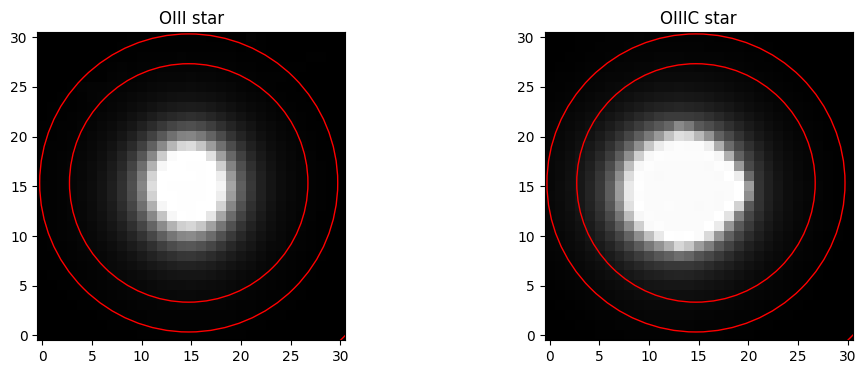

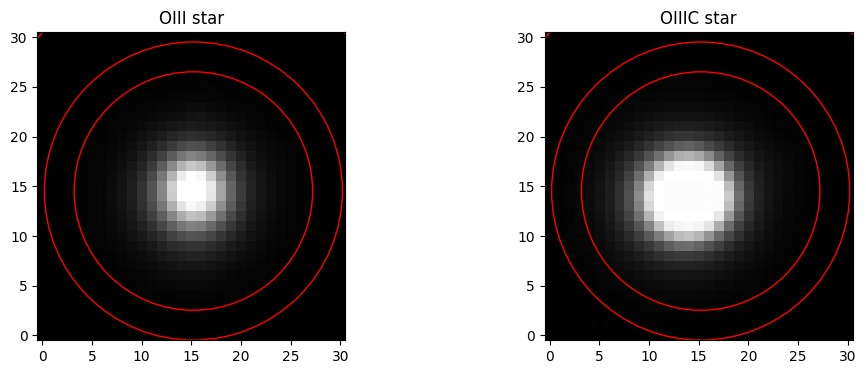

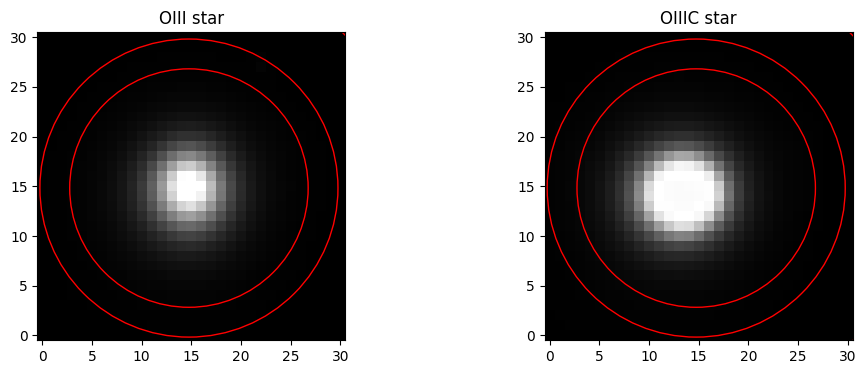

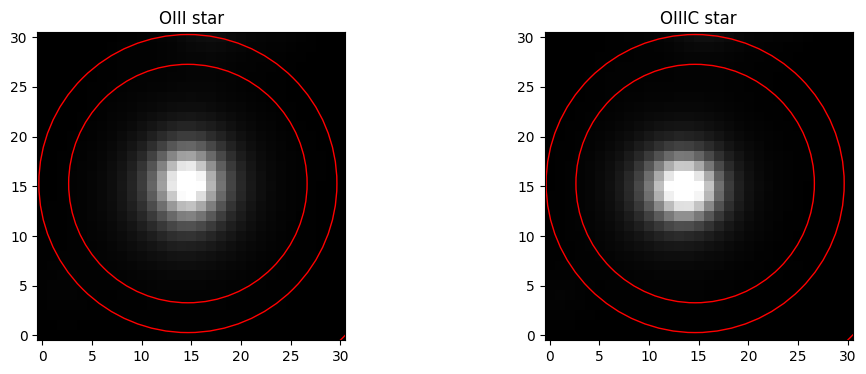

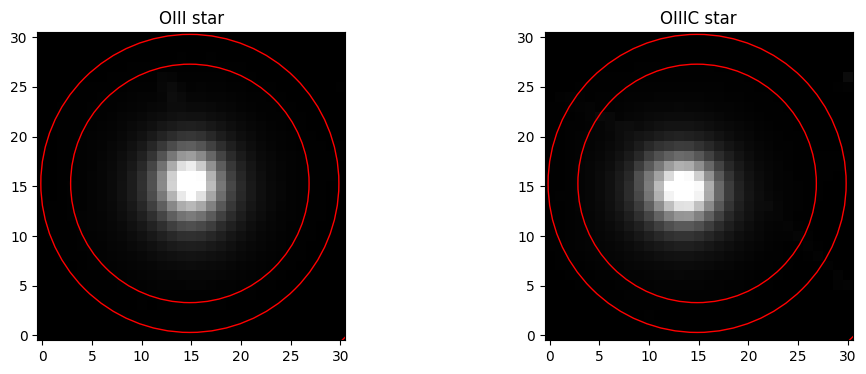

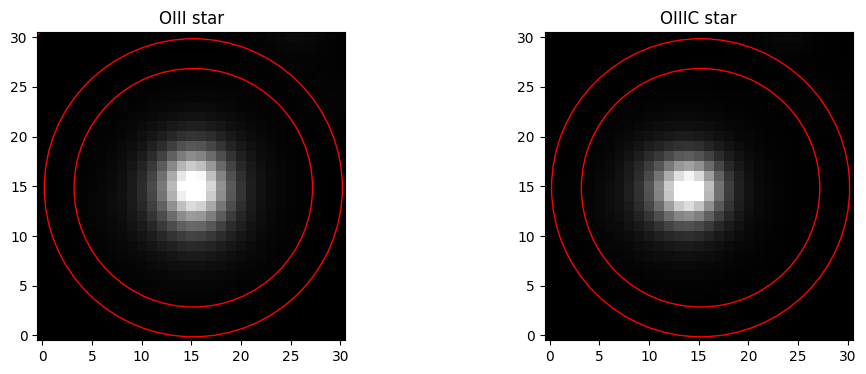

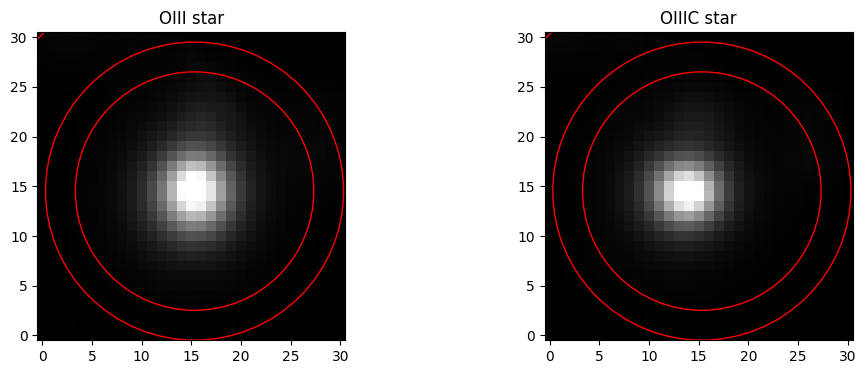

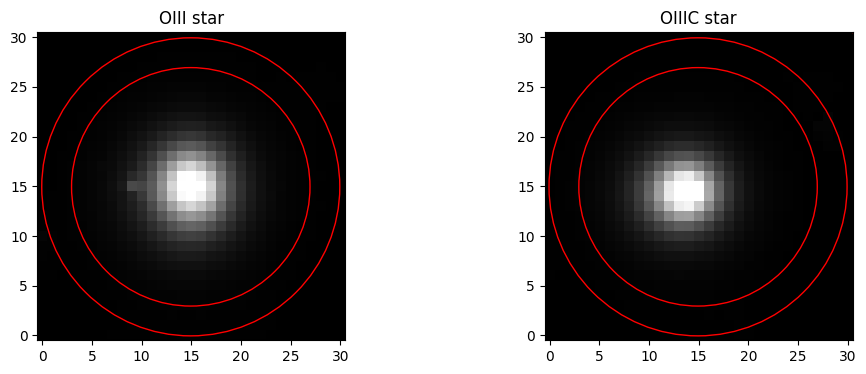

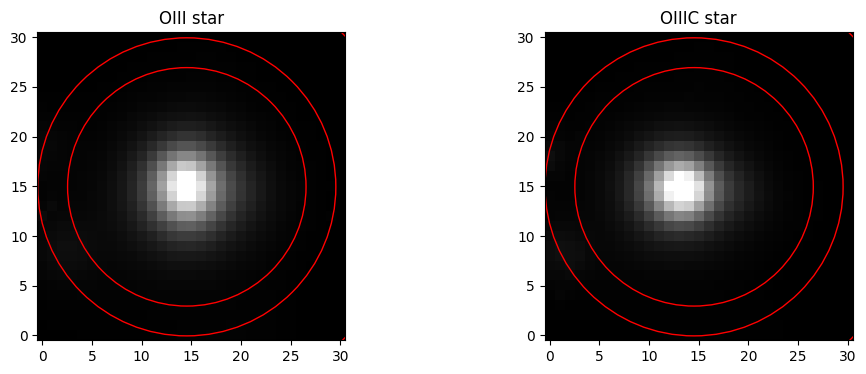

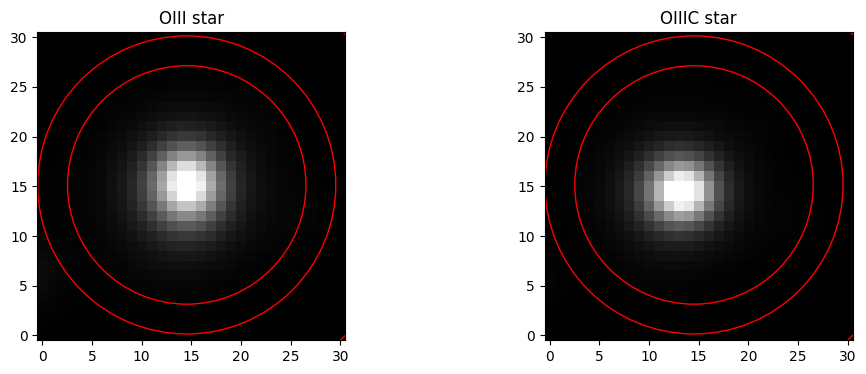

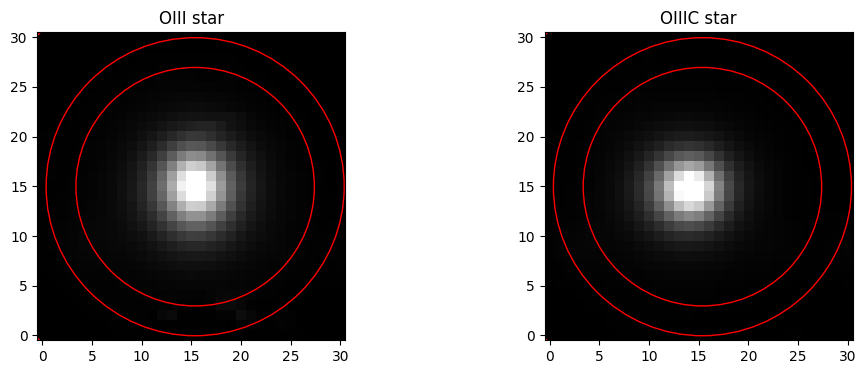

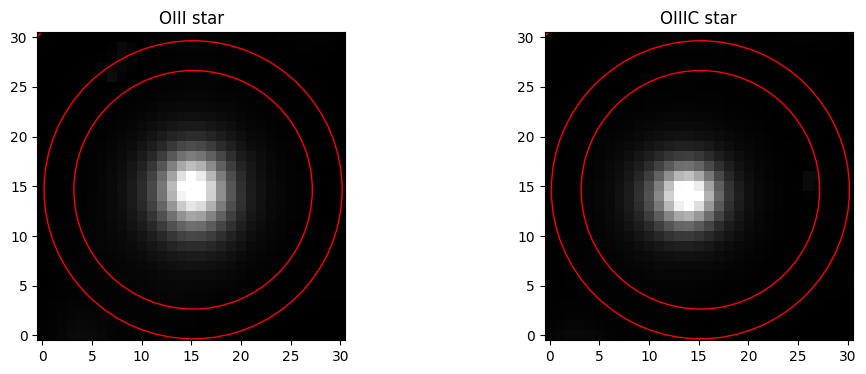

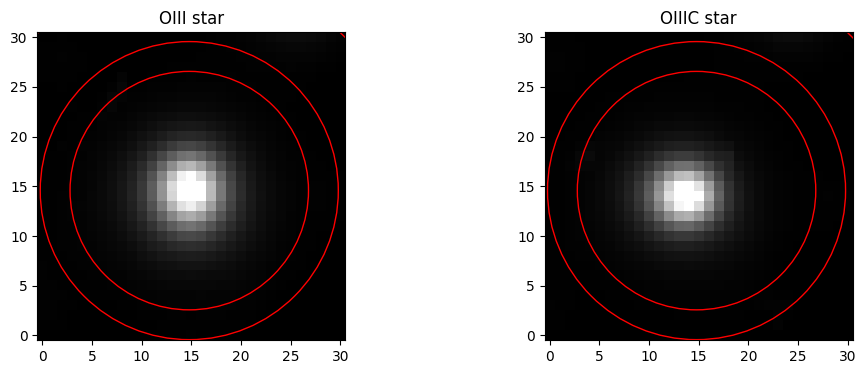

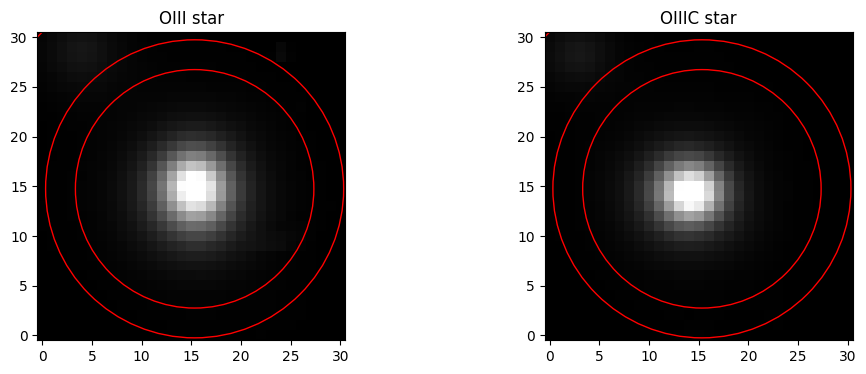

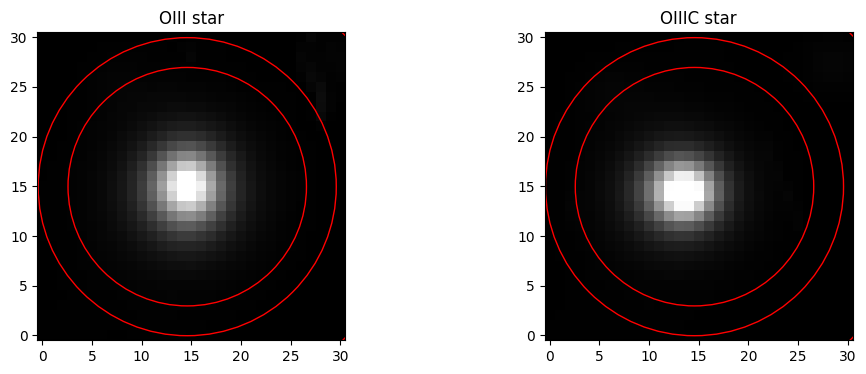

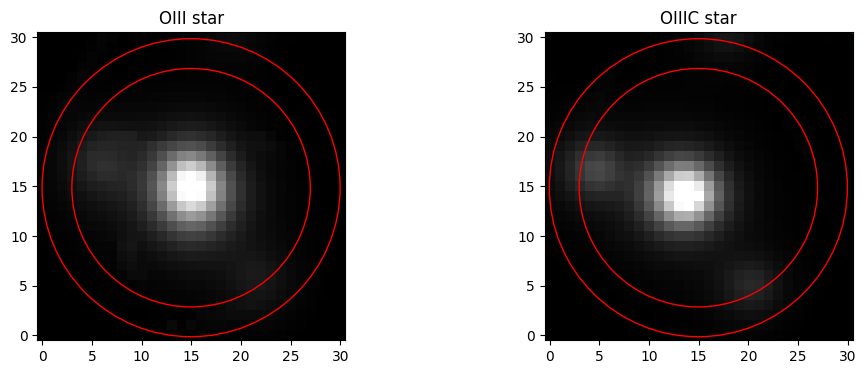

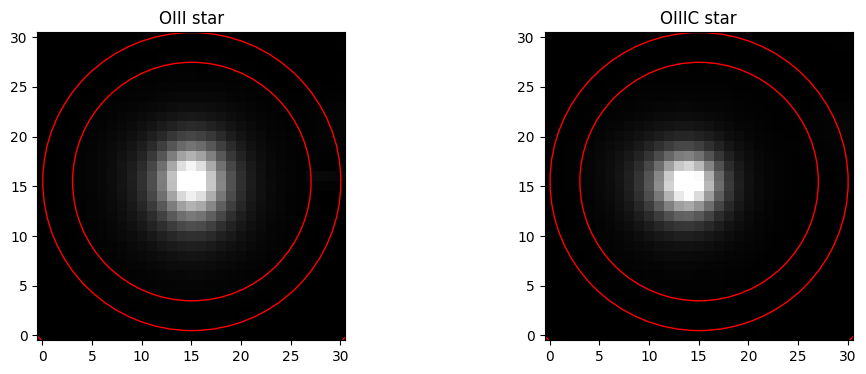

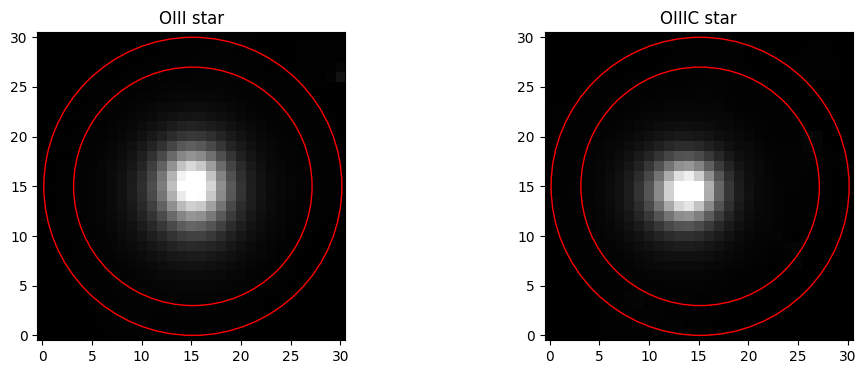

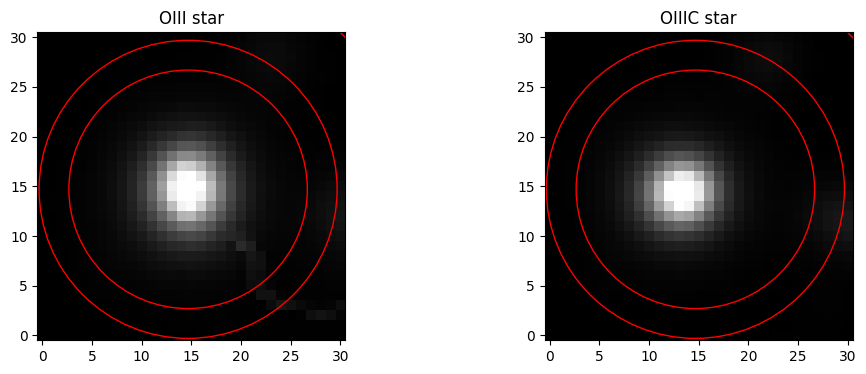

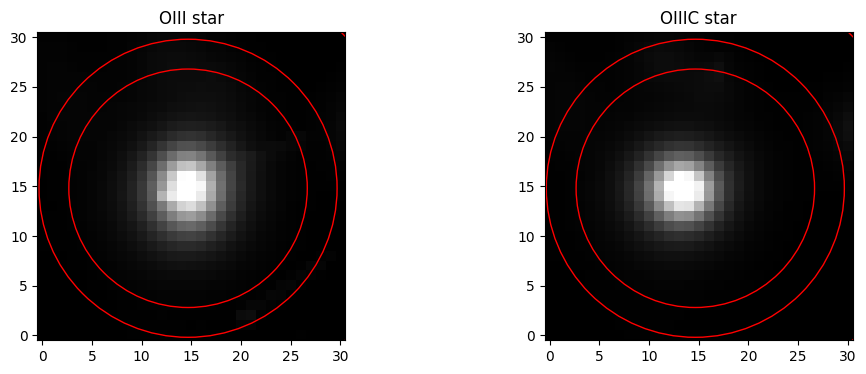

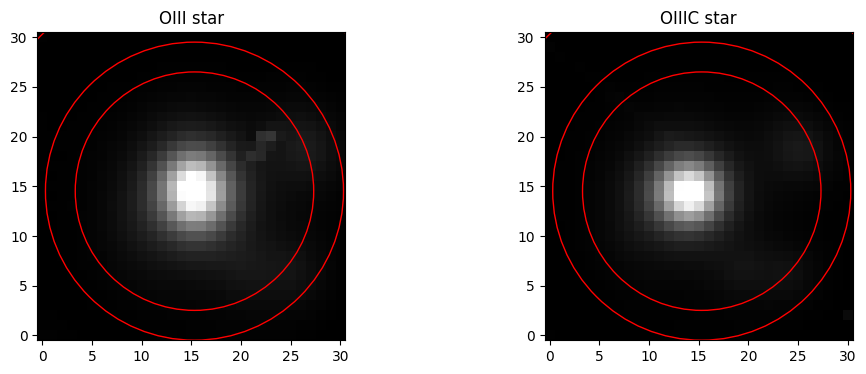

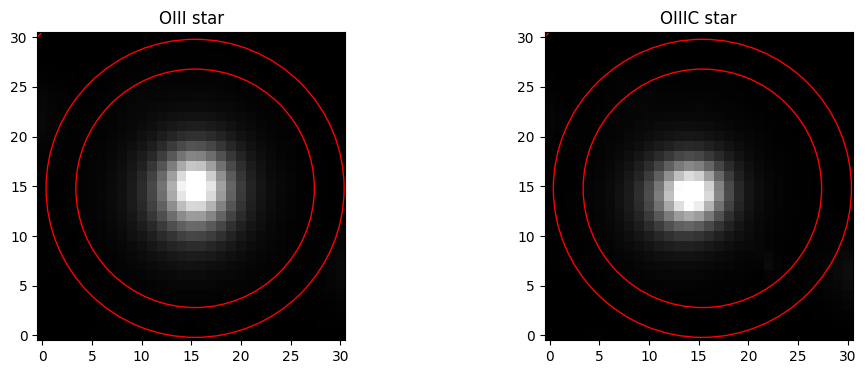

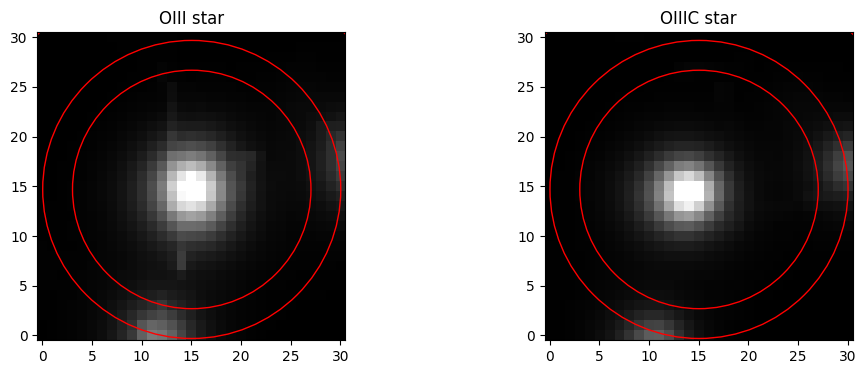

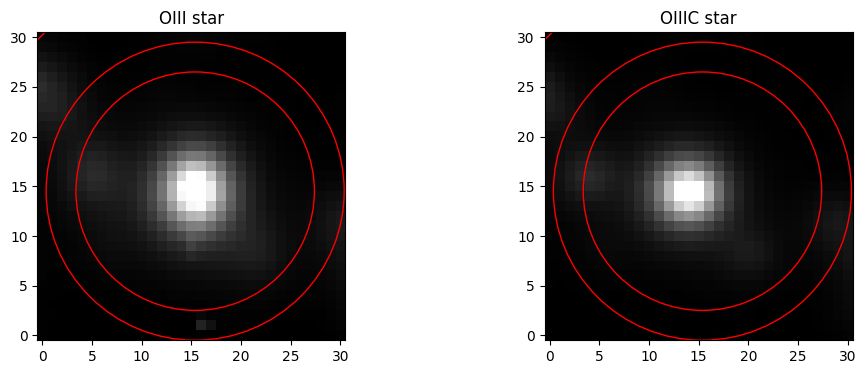

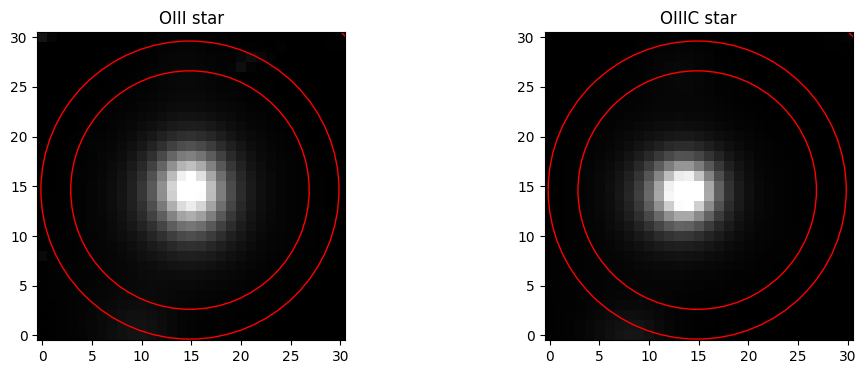

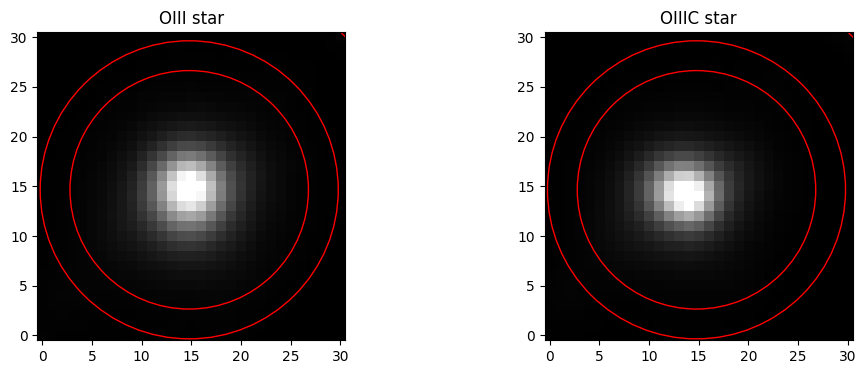

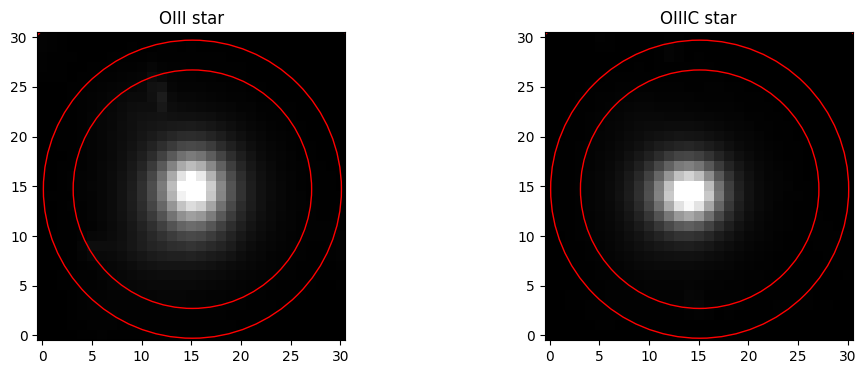

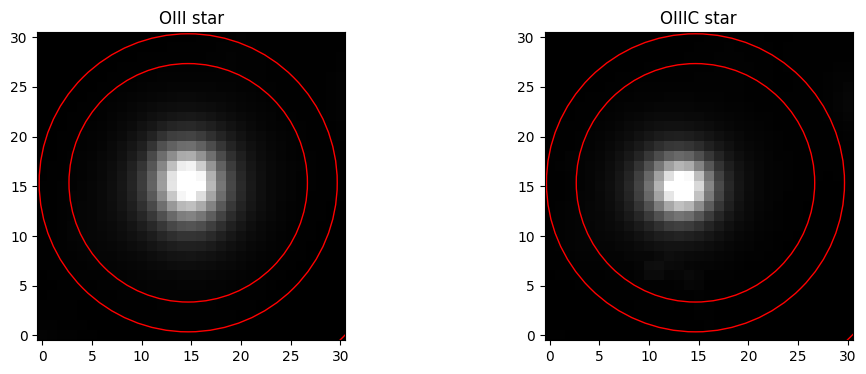

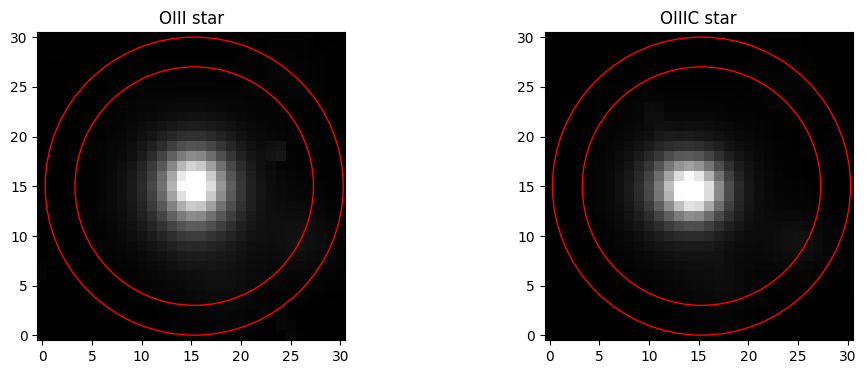

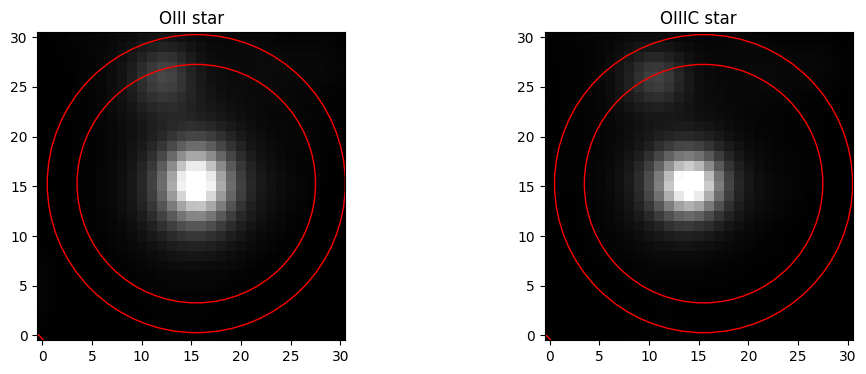

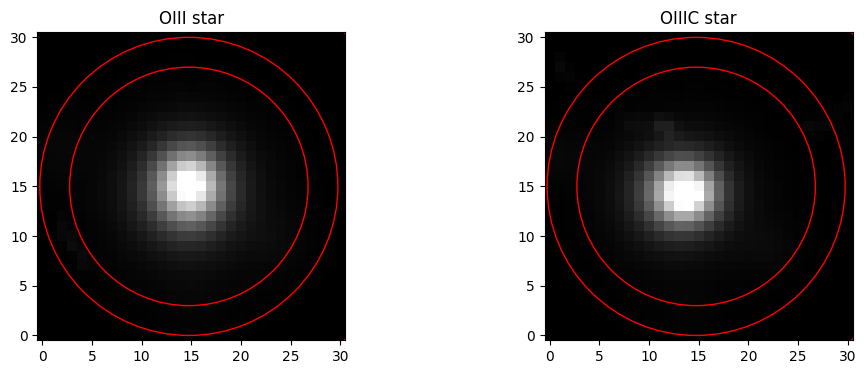

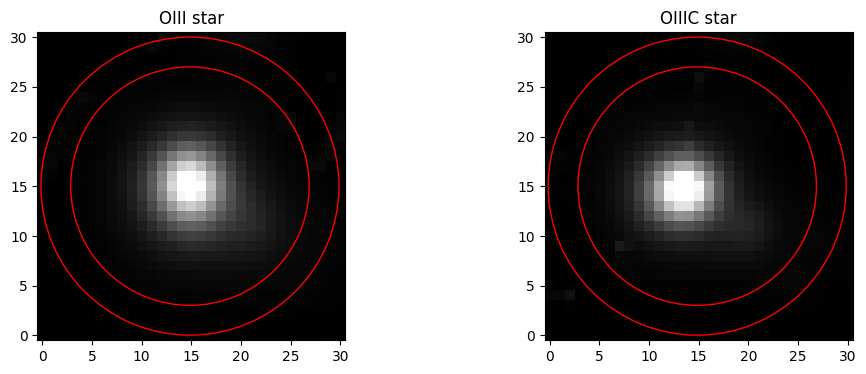

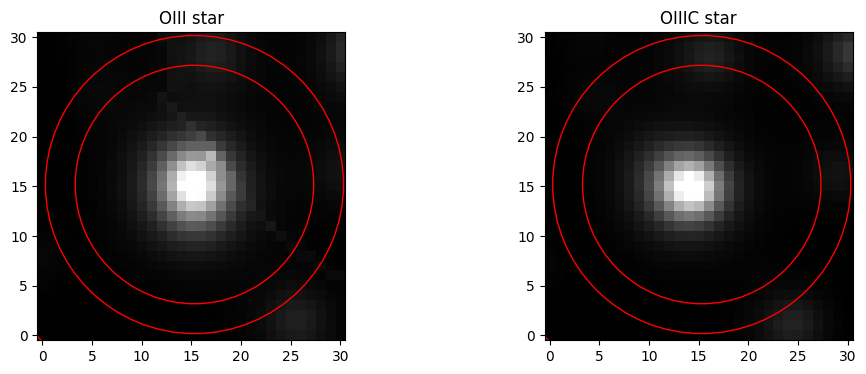

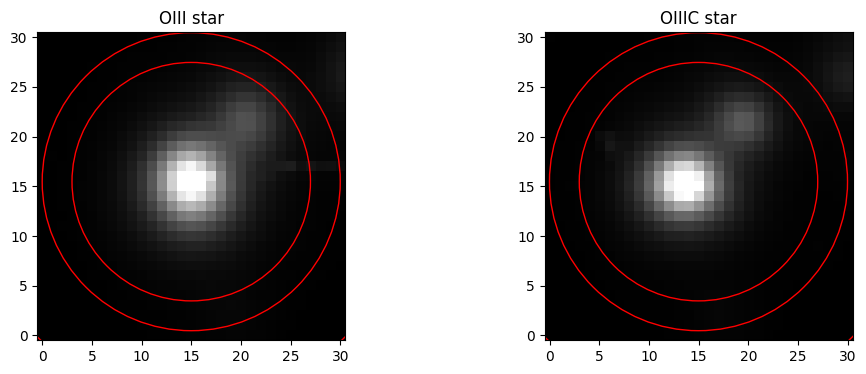

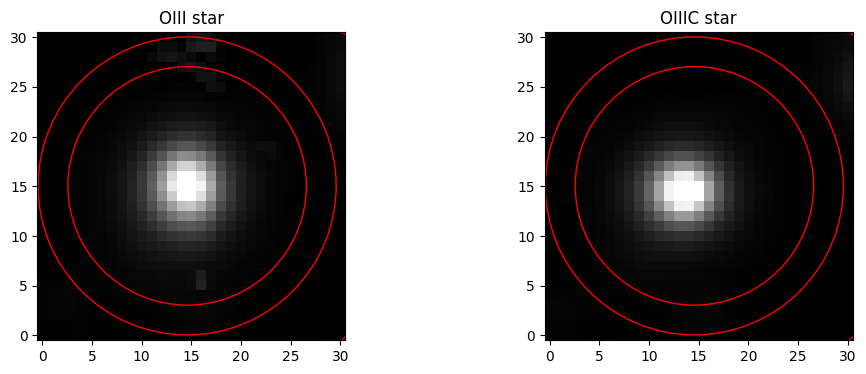

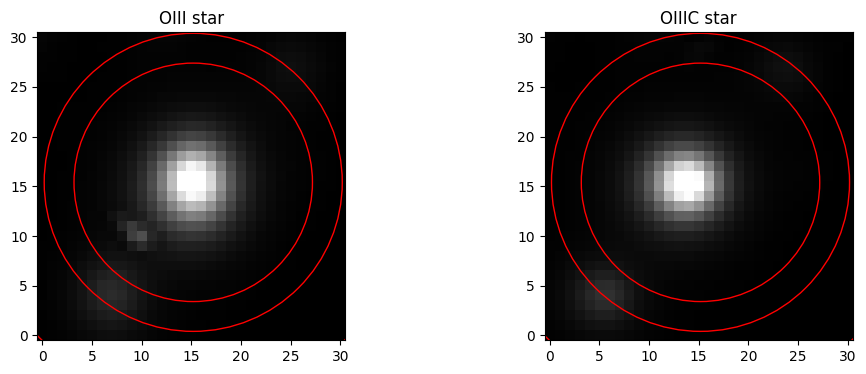

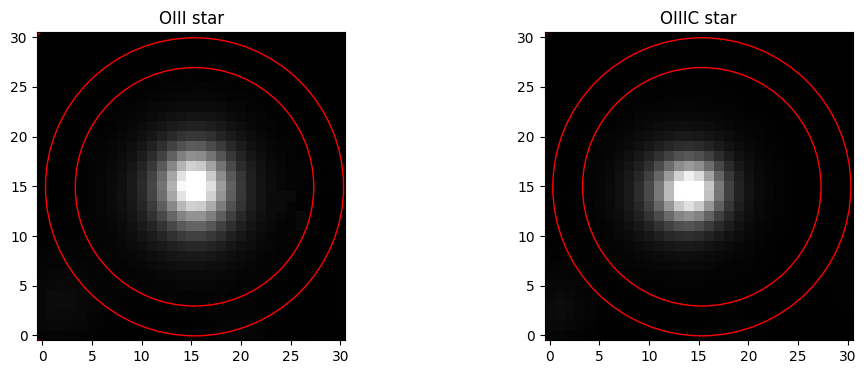

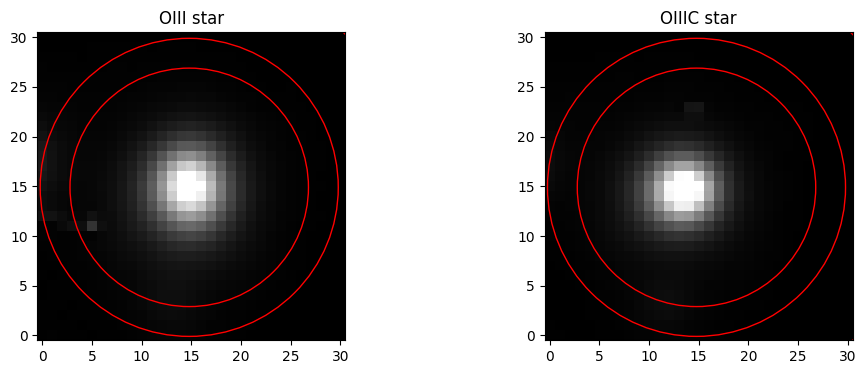

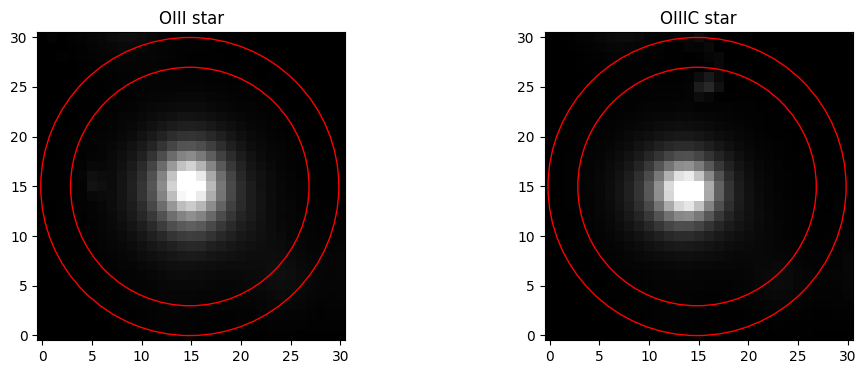

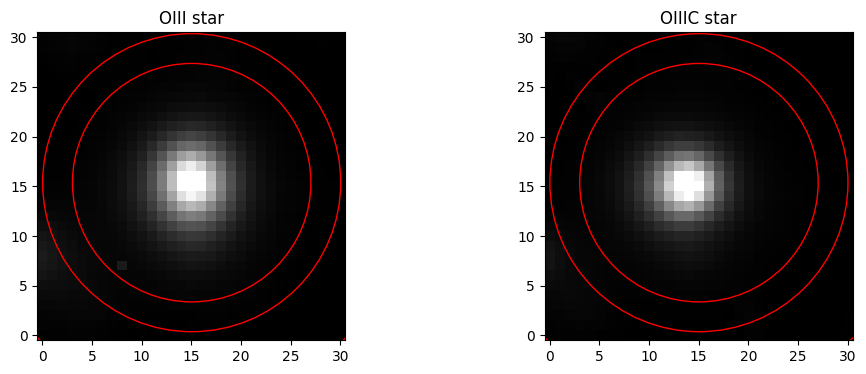

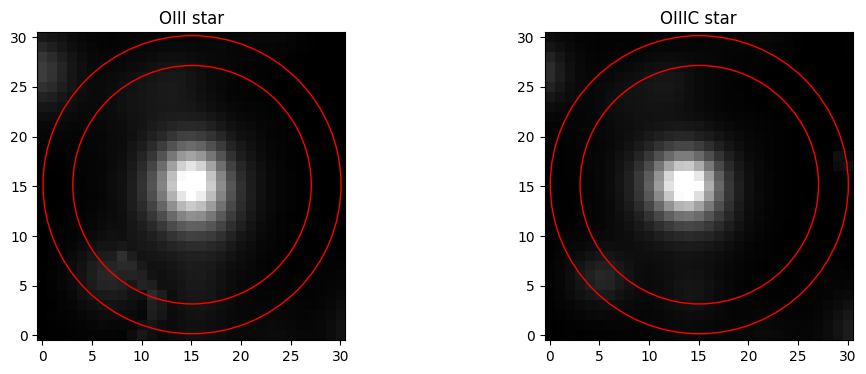

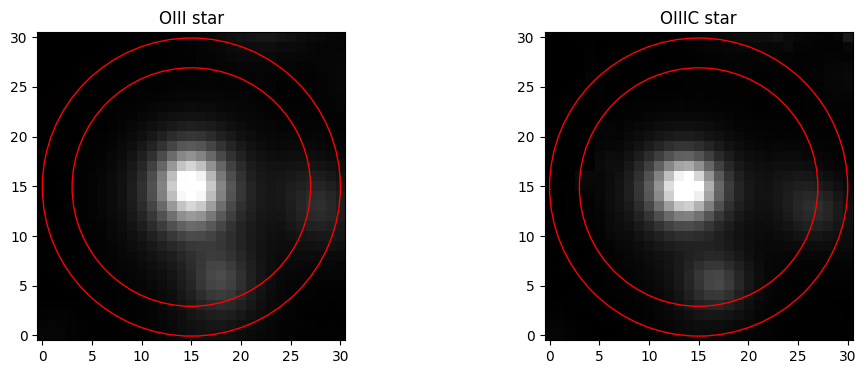

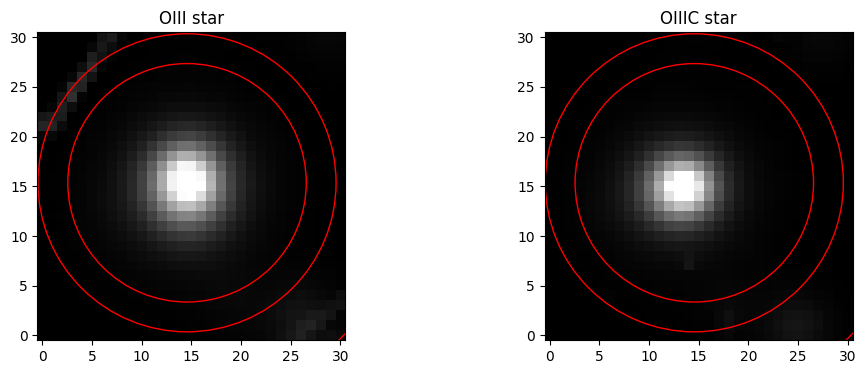

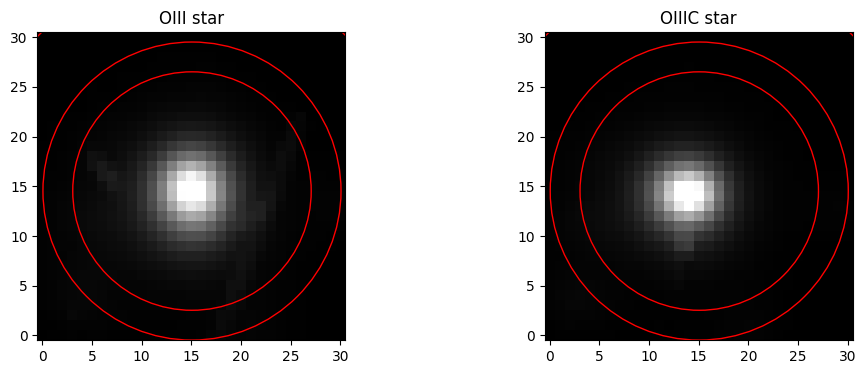

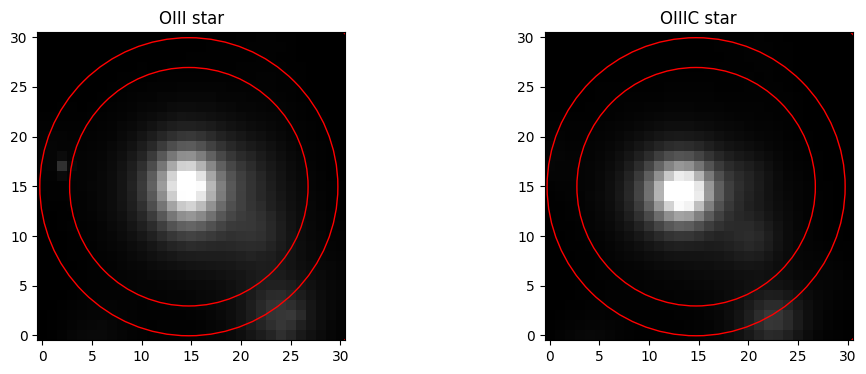

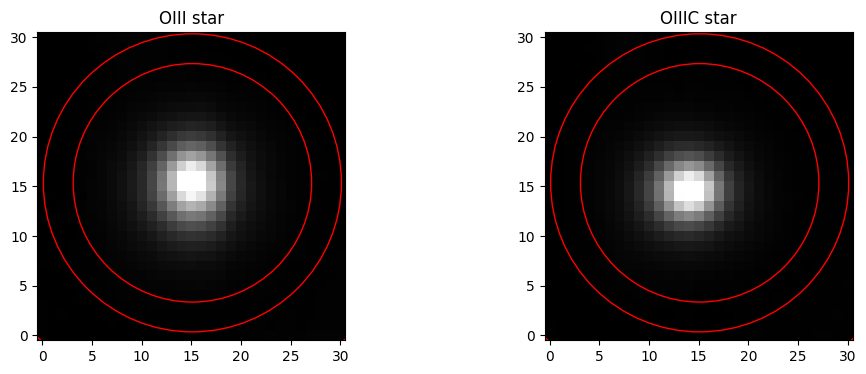

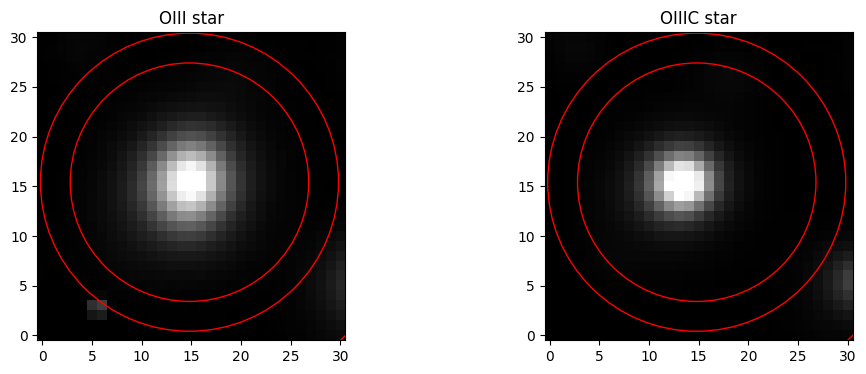

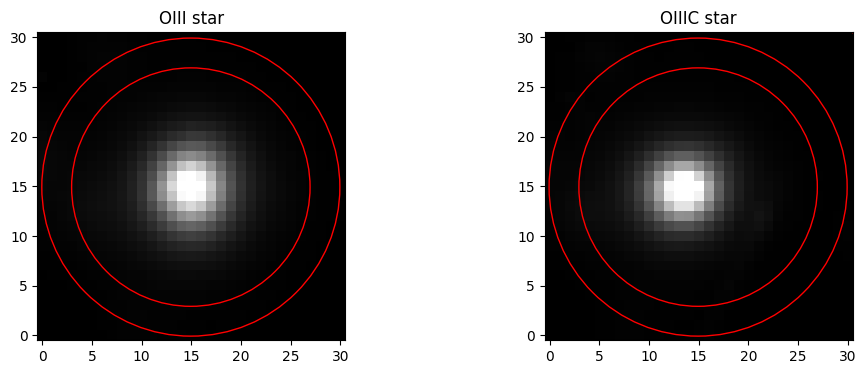

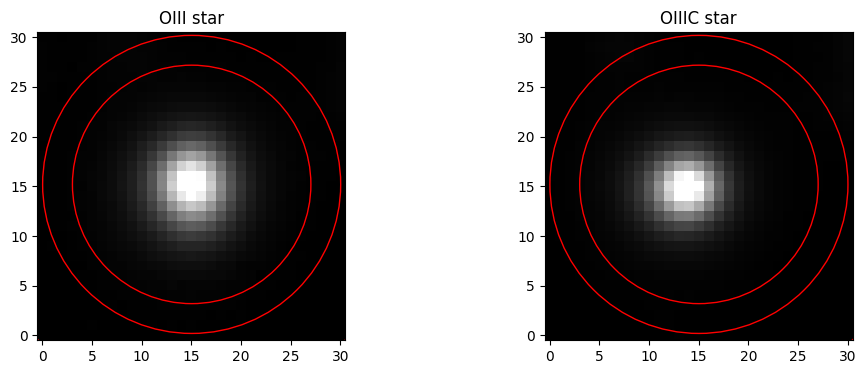

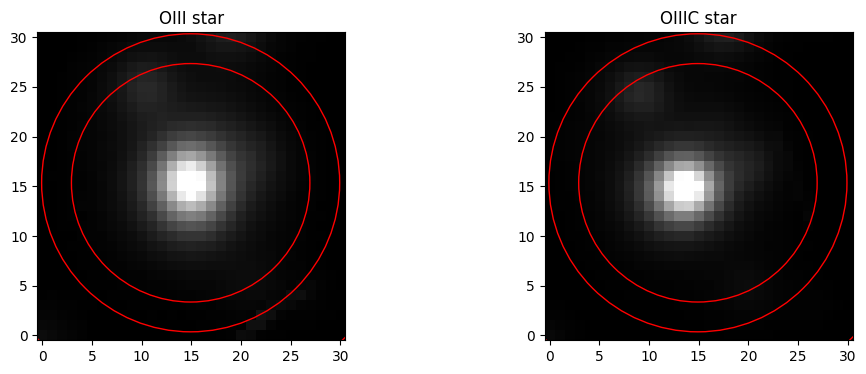

In [213]:
# cut out the detected stars and apply to both images



for star in brightest:
    
    # create cutouts for stars
    x = star["x_centroid"]
    y = star["y_centroid"]

    cutout_oiii = Cutout2D(oiii_image, (x, y), size=31)
    cutout_oiiic = Cutout2D(oiiic_image, (x, y), size=31)
    star_oiii = cutout_oiii.data
    star_oiiic = cutout_oiiic.data
    
    # oiii aperture drawing
    pos_oiii = cutout_oiii.input_position_cutout      # local cutout coords
    aperture_oiii = CircularAperture(pos_oiii, r=12)
    annulus_oiii = CircularAnnulus(pos_oiii, r_in=15, r_out=22)
    
    pos_oiiic = cutout_oiiic.input_position_cutout     # local cutout coords
    aperture_oiiic = CircularAperture(pos_oiiic, r=12)
    annulus_oiiic = CircularAnnulus(pos_oiiic, r_in=15, r_out=22)

    # aperture sum measurment
    oiii_sum = aperture_photometry(star_oiii, aperture_oiii)
    oiiic_sum = aperture_photometry(star_oiiic, aperture_oiiic)
    oiii_raw = float(oiii_sum["aperture_sum"][0])
    oiiic_raw = float(oiiic_sum["aperture_sum"][0])
    
    # background measurement
    annulus_stats_oiii = ApertureStats(star_oiii, annulus_oiii, sigma_clip=SigmaClip(sigma=3.0))
    annulus_stats_oiiic = ApertureStats(star_oiiic, annulus_oiiic, sigma_clip=SigmaClip(sigma=3.0))

    bkg_oiii = annulus_stats_oiii.median * annulus_oiii.area
    bkg_oiiic = annulus_stats_oiiic.median * annulus_oiiic.area

    # calculate net background subtracted sum
    oiii_rate = oiii_raw - bkg_oiii
    oiiic_rate = oiiic_raw - bkg_oiiic
    
    # flux ratio for subtraction factor
    flux_ratio = oiii_rate / oiiic_rate
   
    # add values to the table
    cal_table.add_row({
        "x_centroid": x * u.pix,
        "y_centroid": y * u.pix,
        "oiii_raw_sum": oiii_raw * u.electron / u.s,
        "oiiic_raw_sum": oiiic_raw * u.electron / u.s,
        "oiii_rate": oiii_rate * u.electron / u.s,
        "oiiic_rate": oiiic_rate * u.electron / u.s,
        "flux_ratio": flux_ratio
    })
   
   
   
   
   
   
   
    # plot star previews
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
    ax1.set_title("OIII star")

    ax2.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
    ax2.set_title("OIIIC star")

    aperture_oiii.plot(ax=ax1, color="red")
    annulus_oiii.plot(ax=ax1, color="red")
    aperture_oiiic.plot(ax=ax2, color="red")
    annulus_oiii.plot(ax=ax2, color="red")


    plt.show()


In [214]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,flux_ratio
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,0.0,0.0,0,0.0,0.0,,0.674869
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,0.0,0.0,0,0.0,0.0,,0.556426
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,0.0,0.0,0,0.0,0.0,,0.501016
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,0.0,0.0,0,0.0,0.0,,0.414345
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,0.0,0.0,0,0.0,0.0,,0.389025
5,1566.199258,1677.852190,279.390065,822.293717,230.398358,703.215090,0.0,0.0,0,0.0,0.0,,0.327636
6,2466.324054,1997.516436,252.444373,631.549985,202.152284,519.642897,0.0,0.0,0,0.0,0.0,,0.389022
7,1434.942358,638.944208,239.091109,564.508872,196.297371,470.059332,0.0,0.0,0,0.0,0.0,,0.417601
8,1289.542878,2047.943487,243.484464,603.197682,202.984679,518.948562,0.0,0.0,0,0.0,0.0,,0.391146
9,995.536256,274.135866,228.586280,835.910732,187.504848,740.745318,0.0,0.0,0,0.0,0.0,,0.253130


In [215]:
# compute median scale factor for image subtraction
np.nanmedian(cal_table["flux_ratio"])

0.3950555310161904

In [217]:
# lookup Gaia stats for each star in the table

radius = 2/3600 # 2 arcsec

for i, row in enumerate(cal_table):
    
    x = row["x_centroid"]
    y = row["y_centroid"]
    coord = wcs.pixel_to_world(x, y)
    
    
    query = f"""
    SELECT TOP 1 g.source_id, g.ra, g.dec, g.phot_bp_mean_mag, ap.teff_gspphot, ap.spectraltype_esphs
    FROM gaiadr3.gaia_source AS g
    LEFT OUTER JOIN gaiadr3.astrophysical_parameters AS ap
    ON g.source_id = ap.source_id
    WHERE 1 = CONTAINS(
    POINT('ICRS', g.ra, g.dec),
    CIRCLE(
        'ICRS',
        {coord.ra.deg},
        {coord.dec.deg},
        {radius}
        )
    )
    """
    
    job = Gaia.launch_job(query)
    result = job.get_results()
    
    
    if len(result) > 0:
        
        match = result[0]
        cal_table["ra"][i] = match["ra"] * u.deg
        cal_table["dec"][i] = match["dec"] * u.deg
        cal_table["source_id"][i] = str(match["SOURCE_ID"])
        cal_table["phot_bp_mean_mag"][i] = match["phot_bp_mean_mag"] * u.mag
        cal_table["teff_gspphot"][i] = match["teff_gspphot"] * u.K
        cal_table["spectraltype_esphs"][i] = match["spectraltype_esphs"]
    
    print(f"{i + 1}/{len(cal_table)} done", end="\r", flush=True)
    print(result)
    

     SOURCE_ID              ra        ... teff_gspphot spectraltype_esphs
                           deg        ...      K                         
------------------- ----------------- ... ------------ ------------------
4656999405200489984 86.94127847787384 ...     5709.822                  F
     SOURCE_ID              ra        ... teff_gspphot spectraltype_esphs
                           deg        ...      K                         
------------------- ----------------- ... ------------ ------------------
4656999542639412480 86.91920864008915 ...     5459.562                  G
     SOURCE_ID              ra        ... teff_gspphot spectraltype_esphs
                           deg        ...      K                         
------------------- ----------------- ... ------------ ------------------
4656999508279668992 86.90608364300277 ...     5764.995                  K
     SOURCE_ID              ra        ... teff_gspphot spectraltype_esphs
                           deg        

In [218]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,flux_ratio
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,86.941278,-70.398233,4656999405200489984,13.614061,5709.821777,F,0.674869
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,86.919209,-70.376929,4656999542639412480,14.214470,5459.562012,G,0.556426
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,86.906084,-70.381336,4656999508279668992,14.458078,5764.995117,K,0.501016
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,87.028780,-70.379017,4656999675756956544,15.241419,5944.969727,G,0.414345
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,86.831825,-70.394552,4657000195474396672,16.097672,6036.355957,F,0.389025
5,1566.199258,1677.852190,279.390065,822.293717,230.398358,703.215090,87.031063,-70.421639,4656999130322671616,16.246441,0.000000,F,0.327636
6,2466.324054,1997.516436,252.444373,631.549985,202.152284,519.642897,87.041269,-70.463886,4656990231148711168,16.227287,5636.097168,G,0.389022
7,1434.942358,638.944208,239.091109,564.508872,196.297371,470.059332,86.902199,-70.404092,4656999370840727680,16.316359,9682.519531,F,0.417601
8,1289.542878,2047.943487,243.484464,603.197682,202.984679,518.948562,87.087814,-70.413944,4656996308502374656,16.120211,4788.275391,K,0.391146
9,995.536256,274.135866,228.586280,835.910732,187.504848,740.745318,86.870662,-70.381055,4656999473919906944,16.325615,6128.712402,F,0.253130


In [219]:
cal_table.write("calibration_table_backup.fits", overwrite=True)

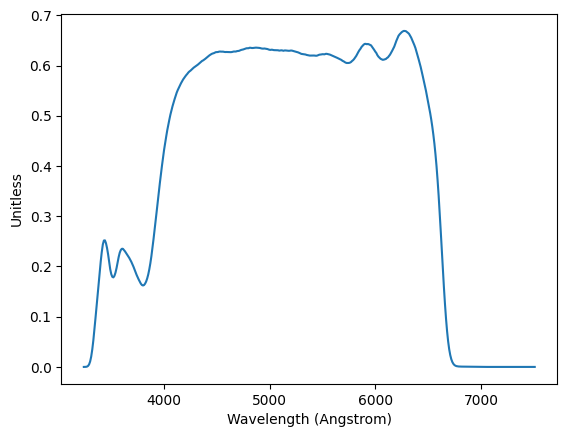

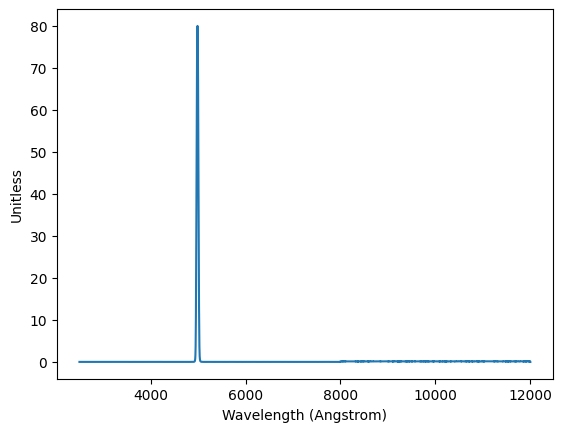

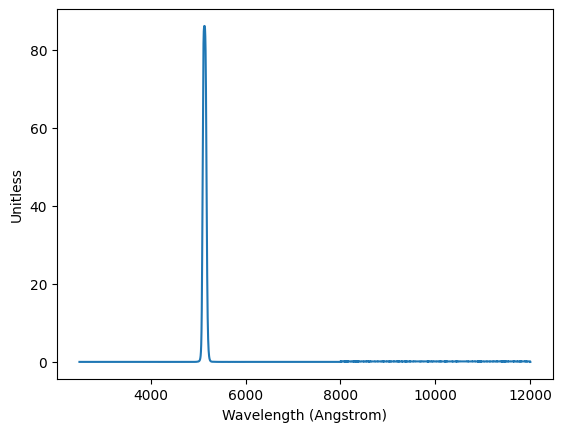

In [242]:
# import all filters for scaling and integration

gaia_bp = SpectralElement.from_file("filters/gaia_bp.fits")
gaia_bp.plot()

gmos_oiii = SpectralElement.from_file("filters/gmos_oiii.fits")
gmos_oiii.plot()

gmos_oiiic = SpectralElement.from_file("filters/gmos_oiiic.fits")
gmos_oiiic.plot()


In [ ]:
# create the full columns for storing the simulated flux and ratios
#TODO: fix the dict design at the top for the table

In [264]:
# calculate the simulated flux for each star

# vega source for magnitude conversion
vega = SourceSpectrum.from_vega()
 
# use this since pickles is more precise than just a class type
spectral_map = {
    "A": "a5v",
    "B": "b57v",
    "F": "f5v",
    "G": "g5v",
    "K": "k5v",
    "M": "m5v",
}


for i, row in enumerate(cal_table):
    

    spectral_class = cal_table["spectraltype_esphs"][i].strip().upper()
    bp_mag = cal_table["phot_bp_mean_mag"][i].to_value(u.mag)

    spec_name = spectral_map.get(spectral_class)

    if spec_name is None:
        print("skip this entry no type available")
        
    else:
        spectrum = Spextrum(f"pickles/{spec_name}")
        scaled_spectum = spectrum.normalize(bp_mag * su.VEGAMAG, band=gaia_bp, vegaspec=vega)
        
        
        obs_oiii = Observation(scaled_spectum, gmos_oiii)
        photon_flux_oiii = obs_oiii.integrate(flux_unit=su.FLAM)

        obs_oiiic = Observation(scaled_spectum, gmos_oiiic)
        photon_flux_oiiic = obs_oiiic.integrate(flux_unit=su.FLAM)
        
        simulated_ratio = photon_flux_oiii / photon_flux_oiiic

        
        # store values in the table
        
        cal_table["simulated_oiii_flux"][i] = photon_flux_oiii
        cal_table["simulated_oiiic_flux"][i] = photon_flux_oiiic
        cal_table["simulated_ratio"][i] = simulated_ratio
        

        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead

skip this entry no type available
skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]


skip this entry no type available


        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead. [spextra.spextra]
        Use TUNITn as per FITS standards instead

skip this entry no type available


In [262]:
df = cal_table.to_pandas()
df

,x_centroid,y_centroid,oiii_raw_sum,oiiic_raw_sum,oiii_rate,oiiic_rate,ra,dec,source_id,phot_bp_mean_mag,teff_gspphot,spectraltype_esphs,flux_ratio,simulated_ratio,simulated_oiii_flux,simulated_oiiic_flux
0,1230.733929,889.336016,2088.434594,3140.645213,1949.412094,2888.580653,86.941278,-70.398233,4656999405200489984,13.614061,5709.821777,F,0.674869,0.494201,2.225421e-07,4.503070e-07
1,811.205426,604.520964,1428.152045,2588.768327,1340.856603,2409.764610,86.919209,-70.376929,4656999542639412480,14.214470,5459.562012,G,0.556426,0.502570,2.333268e-07,4.642670e-07
2,932.757145,534.819993,1109.593914,2212.500426,1032.810708,2061.434017,86.906084,-70.381336,4656999508279668992,14.458078,5764.995117,K,0.501016,0.599743,1.997927e-07,3.331303e-07
3,643.651202,1416.274626,578.102620,1366.659626,502.434568,1212.599328,87.028780,-70.379017,4656999675756956544,15.241419,5944.969727,G,0.414345,0.502570,2.501839e-07,4.978088e-07
4,1364.849469,69.289549,272.510097,691.389767,233.936063,601.340128,86.831825,-70.394552,4657000195474396672,16.097672,6036.355957,F,0.389025,0.494201,2.631404e-07,5.324565e-07
5,1566.199258,1677.852190,279.390065,822.293717,230.398358,703.215090,87.031063,-70.421639,4656999130322671616,16.246441,0.000000,F,0.327636,0.494201,2.655723e-07,5.373772e-07
6,2466.324054,1997.516436,252.444373,631.549985,202.152284,519.642897,87.041269,-70.463886,4656990231148711168,16.227287,5636.097168,G,0.389022,0.502570,2.663667e-07,5.300088e-07
7,1434.942358,638.944208,239.091109,564.508872,196.297371,470.059332,86.902199,-70.404092,4656999370840727680,16.316359,9682.519531,F,0.417601,0.494201,2.667152e-07,5.396899e-07
8,1289.542878,2047.943487,243.484464,603.197682,202.984679,518.948562,87.087814,-70.413944,4656996308502374656,16.120211,4788.275391,K,0.391146,0.599743,2.227613e-07,3.714277e-07
9,995.536256,274.135866,228.586280,835.910732,187.504848,740.745318,86.870662,-70.381055,4656999473919906944,16.325615,6128.712402,F,0.253130,0.494201,2.668665e-07,5.399960e-07


In [265]:
cal_table.write( "calibration_table_with_simulated_flux.fits", overwrite=True)